In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import tensorflow as tf 

PATH = '/content/drive/MyDrive/AI  PROJECT/PlantVillage_Project/PlantVillage'
BATCH_SIZE = 32
IMAGE_SIZE = (56, 56)

train_dataset = tf.keras.utils.image_dataset_from_directory(
    PATH,
    shuffle =True,
    validation_split = 0.2,
    subset = 'training',
    seed = 123, 
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    PATH,
    shuffle = True,
    validation_split = 0.2,
    subset = 'validation',
    seed = 123,
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE
)


Found 2152 files belonging to 3 classes.
Using 1722 files for training.
Found 2152 files belonging to 3 classes.
Using 430 files for validation.


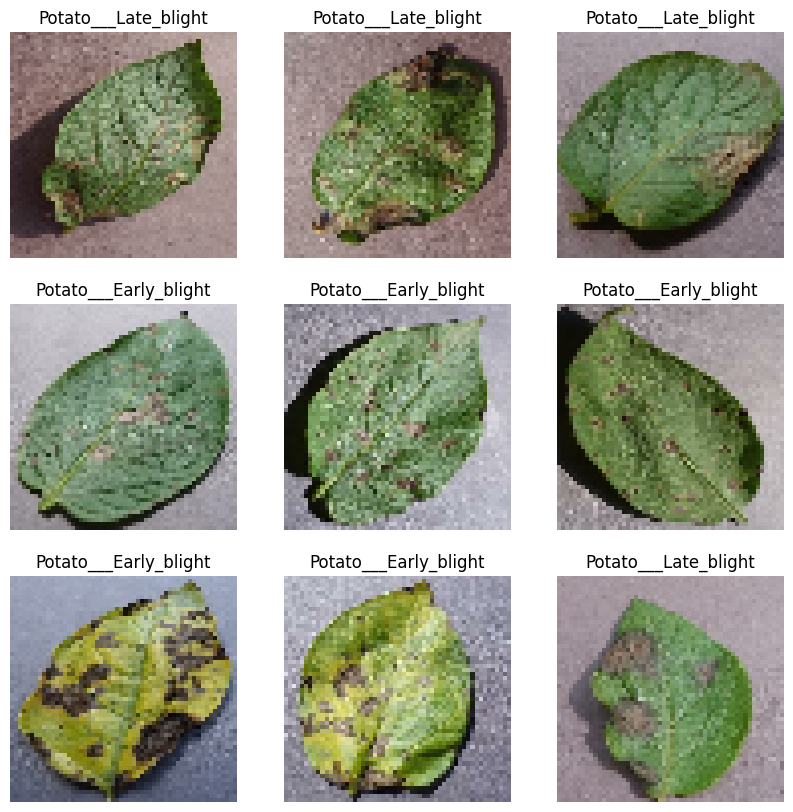

In [3]:
import matplotlib.pyplot as plt

class_name = train_dataset.class_names

plt.figure(figsize=(10,10))
for images, labels, in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_name[labels[i]])
        plt.axis('off')


In [4]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [5]:
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        target = 0.95

        if(logs.get('accuracy')  > target):
            print("Model berhasil mencapai akurasi 90%")
            self.model.stop_training = True

callback = myCallback()

In [6]:
CHANNELS = 3 #KARENA DATA RGB
jumlah_kelas = len(class_name)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1],CHANNELS)),

    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.RandomFlip('Horizontal_and_Vertical'),
    tf.keras.layers.RandomRotation(0.2),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),


    tf.keras.layers.Dense(jumlah_kelas, activation='softmax')
])

model.compile(optimizer='Adam', loss="sparse_categorical_crossentropy", metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 56, 56, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 56, 56, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 56, 56, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 54, 54, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 27, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 503,363 (1.92 MB)

 Trainable params: 503,363 (1.92 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist = model.fit(train_dataset,validation_data = validation_dataset, epochs=50, callbacks=[callback])

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 250ms/step - accuracy: 0.5616 - loss: 0.8524 - val_accuracy: 0.7372 - val_loss: 0.6733
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 189ms/step - accuracy: 0.7805 - loss: 0.5422 - val_accuracy: 0.8093 - val_loss: 0.4646
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 178ms/step - accuracy: 0.8269 - loss: 0.4290 - val_accuracy: 0.8233 - val_loss: 0.4352
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 206ms/step - accuracy: 0.8548 - loss: 0.3680 - val_accuracy: 0.8884 - val_loss: 0.2505
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 163ms/step - accuracy: 0.9053 - loss: 0.2516 - val_accuracy: 0.9372 - val_loss: 0.1541
Epoch 6/50


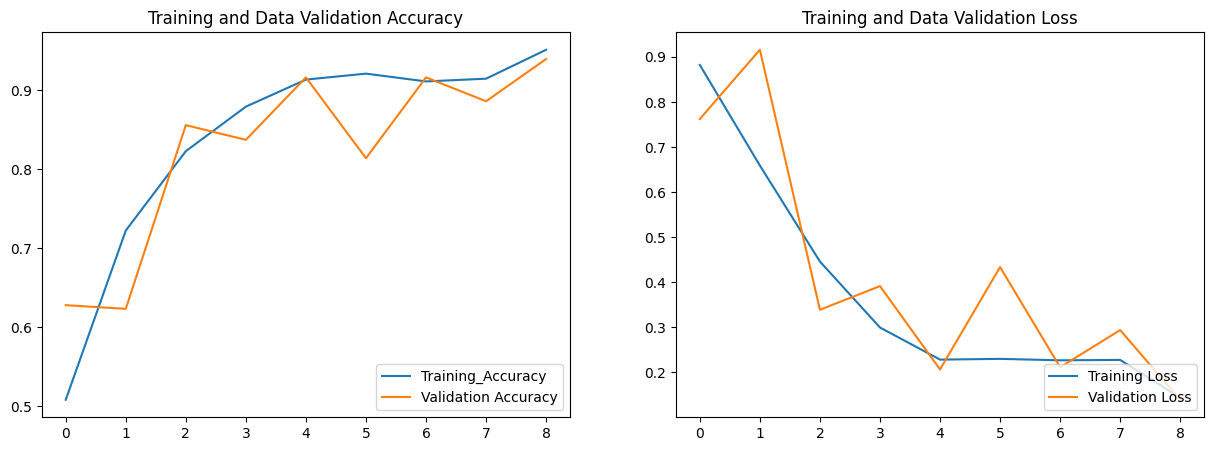

In [ ]:
acc = hist.history['accuracy']
val_acc = hist.history['val_accuracy']
loss = hist.history['loss']
val_loss = hist.history['val_loss']

epoch_range = range(len(acc))

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(epoch_range, acc, label='Training_Accuracy')
plt.plot(epoch_range, val_acc, label='Validation Accuracy')
plt.title("Training and Data Validation Accuracy")
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epoch_range, loss, label='Training Loss')
plt.plot(epoch_range, val_loss, label='Validation Loss')
plt.title("Training and Data Validation Loss")
plt.legend(loc='lower right')
plt.show()

In [ ]:
acc

[0.5081300735473633,
 0.7224158048629761,
 0.8228803873062134,
 0.8792102336883545,
 0.9134727120399475,
 0.9210220575332642,
 0.911149799823761,
 0.9146341681480408,
 0.9512194991111755]